In [2]:
import pandas as pd
import numpy as np

print("✔ Libraries loaded!")
base = r"C:\Users\Shyam\Documents\Python\VS code and SQL\Marketing Campaign Analysis System"

nykaa   = pd.read_csv(base + r"\nykaa_campaign_data_with_nulls.csv",   encoding="latin-1")
purplle = pd.read_csv(base + r"\purplle_campaign_data_with_nulls.csv", encoding="latin-1")
tira    = pd.read_csv(base + r"\tira_campaign_data_with_nulls.csv",    encoding="latin-1")

print("✔ All 3 files loaded!")
print(f"nykaa   : {nykaa.shape}")
print(f"purplle : {purplle.shape}")
print(f"tira    : {tira.shape}")

✔ Libraries loaded!
✔ All 3 files loaded!
nykaa   : (55555, 16)
purplle : (55555, 16)
tira    : (55555, 16)


In [3]:
nykaa['Brand']   = 'Nykaa'
purplle['Brand'] = 'Purplle'
tira['Brand']    = 'Tira'

df = pd.concat([nykaa, purplle, tira], ignore_index=True)

print(df.shape)
print(df['Brand'].value_counts())

(166665, 17)
Brand
Nykaa      55555
Purplle    55555
Tira       55555
Name: count, dtype: int64


In [4]:
df.info()
print("\nMissing values:\n", df.isnull().sum())
print("\nDuplicates:", df.duplicated().sum())

<class 'pandas.DataFrame'>
RangeIndex: 166665 entries, 0 to 166664
Data columns (total 17 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Campaign_ID       161248 non-null  str    
 1   Campaign_Type     158307 non-null  str    
 2   Target_Audience   158493 non-null  str    
 3   Duration          158342 non-null  float64
 4   Channel_Used      158383 non-null  str    
 5   Impressions       158441 non-null  float64
 6   Clicks            158441 non-null  float64
 7   Leads             158575 non-null  float64
 8   Conversions       158665 non-null  float64
 9   Revenue           158361 non-null  float64
 10  Acquisition_Cost  158504 non-null  float64
 11  ROI               158367 non-null  float64
 12  Language          158366 non-null  str    
 13  Engagement_Score  158584 non-null  float64
 14  Customer_Segment  158490 non-null  str    
 15  Date              158566 non-null  str    
 16  Brand             166665 non-nu

In [5]:
#Handle Missing Values
# Numerical — fill with median
numerical_cols = ['Duration', 'Impressions', 'Clicks', 'Leads',
                  'Conversions', 'Engagement_Score']
for col in numerical_cols:
    df[col] = df[col].fillna(df[col].median())

# Acquisition_Cost — fill with mean
df['Acquisition_Cost'] = df['Acquisition_Cost'].fillna(df['Acquisition_Cost'].mean())

# Revenue — drop nulls instead of filling with 0 (Bug 5 fix)
df = df.dropna(subset=['Revenue'])

# Categorical — fill with mode
categorical_cols = ['Campaign_Type', 'Target_Audience', 'Channel_Used',
                    'Language', 'Customer_Segment']
for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# Date — forward fill
df['Date'] = df['Date'].ffill()

# Drop Campaign_ID — not needed
df = df.drop(columns=['Campaign_ID'])

print(df.isnull().sum())
print("\nShape after cleaning:", df.shape)

Campaign_Type          0
Target_Audience        0
Duration               0
Channel_Used           0
Impressions            0
Clicks                 0
Leads                  0
Conversions            0
Revenue                0
Acquisition_Cost       0
ROI                 7850
Language               0
Engagement_Score       0
Customer_Segment       0
Date                   0
Brand                  0
dtype: int64

Shape after cleaning: (158361, 16)


In [6]:
#Fix Data Types
# Duration to integer
df['Duration'] = df['Duration'].astype(int)
print("Duration dtype:", df['Duration'].dtype)

# Date to datetime
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)
print("Date dtype:", df['Date'].dtype)
print(df['Date'].head())

Duration dtype: int64
Date dtype: datetime64[us]
0   2025-04-29
1   2025-04-06
2   2025-01-14
3   2025-06-04
4   2024-12-29
Name: Date, dtype: datetime64[us]


In [7]:
#Fix ROI Formula
# Bug 3 Fix: Use Total Spend (Conversions × Acquisition_Cost)
# instead of just Acquisition_Cost alone
df['Total_Spend'] = df['Conversions'] * df['Acquisition_Cost']

df['ROI'] = (df['Revenue'] - df['Total_Spend']) / df['Total_Spend']
df['ROI'] = df['ROI'].replace([float('inf'), float('-inf')], 0)
df['ROI'] = df['ROI'].fillna(0)

print("Min ROI  :", df['ROI'].min())
print("Max ROI  :", df['ROI'].max())
print("Mean ROI :", df['ROI'].mean())
print("Neg ROI  :", (df['ROI'] < 0).sum())
print("Null ROI :", df['ROI'].isnull().sum())

Min ROI  : -0.9988259378425025
Max ROI  : 304.7891203428163
Mean ROI : 2.7866331571599794
Neg ROI  : 39081
Null ROI : 0


In [8]:
#Create Profit Flag
df['Profit_Flag'] = (df['ROI'] > 0).astype(int)
print(df['Profit_Flag'].value_counts())
print("\nProfit campaigns:", (df['Profit_Flag'] == 1).sum())
print("Loss campaigns  :", (df['Profit_Flag'] == 0).sum())
print("\nClass ratio:")
print(df['Profit_Flag'].value_counts(normalize=True).round(3))

Profit_Flag
1    119278
0     39083
Name: count, dtype: int64

Profit campaigns: 119278
Loss campaigns  : 39083

Class ratio:
Profit_Flag
1    0.753
0    0.247
Name: proportion, dtype: float64


In [9]:
#Multi-Label Encoding for Channels
from sklearn.preprocessing import MultiLabelBinarizer

# Split channels by comma
df['Channel_List'] = df['Channel_Used'].apply(
    lambda x: [ch.strip() for ch in x.split(',')])

print("Unique channels:", df['Channel_List'].explode().unique())

# Apply MultiLabelBinarizer
mlb = MultiLabelBinarizer()
channel_encoded = pd.DataFrame(
    mlb.fit_transform(df['Channel_List']),
    columns=['C_U_' + ch.replace(' ', '_') for ch in mlb.classes_],
    index=df.index
)

df = pd.concat([df, channel_encoded], axis=1)

print("New columns added:", channel_encoded.columns.tolist())
print("Shape:", df.shape)
print(channel_encoded.head())

Unique channels: <ArrowStringArray>
['WhatsApp', 'YouTube', 'Google', 'Facebook', 'Instagram', 'Email']
Length: 6, dtype: str
New columns added: ['C_U_Email', 'C_U_Facebook', 'C_U_Google', 'C_U_Instagram', 'C_U_WhatsApp', 'C_U_YouTube']
Shape: (158361, 25)
   C_U_Email  C_U_Facebook  C_U_Google  C_U_Instagram  C_U_WhatsApp  \
0          0             0           0              0             1   
1          0             0           0              0             0   
2          0             0           1              0             1   
3          0             1           0              1             0   
4          0             1           0              1             0   

   C_U_YouTube  
0            1  
1            1  
2            1  
3            1  
4            0  


     Brand  Total_Revenue   Avg_ROI  Total_Campaigns  Profit_Campaigns  \
0    Nykaa   2.719801e+10  2.801977            52743             39774   
1  Purplle   2.711228e+10  2.770149            52792             39647   
2     Tira   2.705983e+10  2.787787            52826             39857   

   Loss_Campaigns  Profit_Rate  
0           12969        75.41  
1           13145        75.10  
2           12969        75.45  


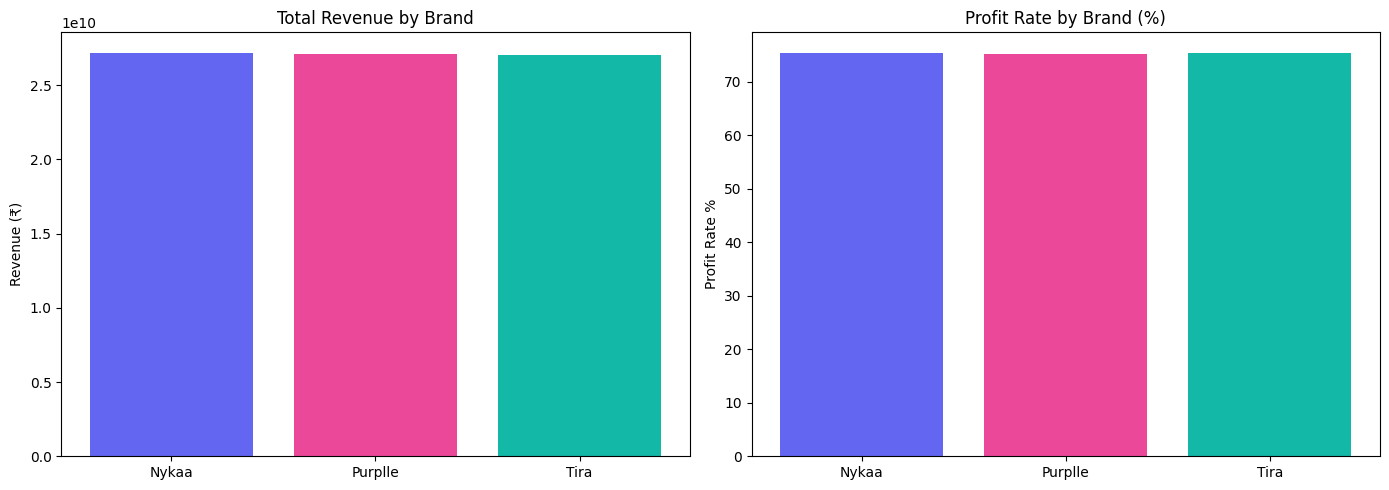

In [10]:
#EDA: Brand-wise Performance
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

brand_summary = df.groupby('Brand').agg(
    Total_Revenue    = ('Revenue',     'sum'),
    Avg_ROI          = ('ROI',         'mean'),
    Total_Campaigns  = ('Brand',       'count'),
    Profit_Campaigns = ('Profit_Flag', 'sum')
).reset_index()

brand_summary['Loss_Campaigns'] = (
    brand_summary['Total_Campaigns'] - brand_summary['Profit_Campaigns']
)
brand_summary['Profit_Rate'] = (
    brand_summary['Profit_Campaigns'] / brand_summary['Total_Campaigns'] * 100
).round(2)

print(brand_summary)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(brand_summary['Brand'], brand_summary['Total_Revenue'],
            color=['#6366f1','#ec4899','#14b8a6'])
axes[0].set_title('Total Revenue by Brand')
axes[0].set_ylabel('Revenue (₹)')

axes[1].bar(brand_summary['Brand'], brand_summary['Profit_Rate'],
            color=['#6366f1','#ec4899','#14b8a6'])
axes[1].set_title('Profit Rate by Brand (%)')
axes[1].set_ylabel('Profit Rate %')

plt.tight_layout()
plt.show()

           Avg_Revenue  Avg_ROI  Avg_Clicks  Profit_Rate_%
Email        515911.13     2.81     4659.37          75.39
Facebook     513870.19     2.76     4657.25          75.32
Google       512868.76     2.79     4623.27          75.20
Instagram    517058.72     2.83     4651.61          75.49
WhatsApp     513291.52     2.76     4648.92          75.55
YouTube      511712.51     2.75     4648.04          75.17


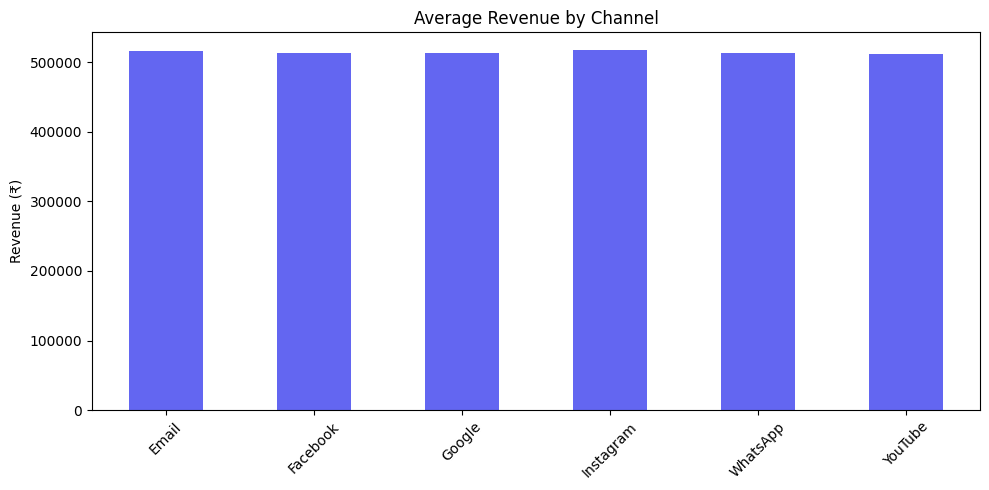

In [11]:
#EDA: Channel-wise Performance
channel_cols = ['C_U_Email','C_U_Facebook','C_U_Google',
                'C_U_Instagram','C_U_WhatsApp','C_U_YouTube']

channel_perf = {}
for ch in channel_cols:
    subset = df[df[ch] == 1]
    channel_perf[ch.replace('C_U_','')] = {
        'Avg_Revenue'     : subset['Revenue'].mean(),
        'Avg_ROI'         : subset['ROI'].mean(),
        'Avg_Clicks'      : subset['Clicks'].mean(),
        'Profit_Rate_%'   : subset['Profit_Flag'].mean() * 100
    }

channel_df = pd.DataFrame(channel_perf).T.round(2)
print(channel_df)

channel_df['Avg_Revenue'].plot(kind='bar', color='#6366f1', figsize=(10,5),
                                title='Average Revenue by Channel')
plt.ylabel('Revenue (₹)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [13]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# ── Encode categorical columns (separate encoders — Bug 4 fix) ────────
le_ct = LabelEncoder()
le_ta = LabelEncoder()
le_cs = LabelEncoder()

df['Campaign_Type_enc']    = le_ct.fit_transform(df['Campaign_Type'])
df['Target_Audience_enc']  = le_ta.fit_transform(df['Target_Audience'])
df['Customer_Segment_enc'] = le_cs.fit_transform(df['Customer_Segment'])

# ── Check Total_Spend exists (from Cell 6) ────────────────────────────
if 'Total_Spend' not in df.columns:
    df['Total_Spend'] = df['Conversions'] * df['Acquisition_Cost']

# ── reg_features: NO ROI, NO Profit_Flag — but ADD Total_Spend ────────
# Total_Spend = Conversions × Acquisition_Cost
# It is NOT leakage — both inputs are known before campaign ends
# Revenue is naturally proportional to total spend, so this is valid
reg_features = [
    'Campaign_Type_enc', 'Target_Audience_enc', 'Customer_Segment_enc',
    'Duration', 'Impressions', 'Clicks', 'Leads',
    'Conversions', 'Acquisition_Cost',
    'Total_Spend',          # ← key feature: strong predictor, no leakage
    'Engagement_Score',
    'C_U_Email', 'C_U_Facebook', 'C_U_Google',
    'C_U_Instagram', 'C_U_WhatsApp', 'C_U_YouTube'
]

# ── Verify all features exist ─────────────────────────────────────────
missing = [f for f in reg_features if f not in df.columns]
if missing:
    print("❌ Missing columns:", missing)
else:
    print("✅ All features present")

X_reg = df[reg_features]
y_reg = df['Revenue']

# ── Log-transform Revenue to handle large skewed values ───────────────
# Revenue is in lakhs — log scale helps Linear Regression especially
y_reg_log = np.log1p(y_reg)

X_train, X_test, y_train, y_test = train_test_split(
    X_reg, y_reg_log, test_size=0.2, random_state=42
)

reg_models = {
    'Linear Regression' : LinearRegression(),
    'Decision Tree'     : DecisionTreeRegressor(random_state=42),
    'Random Forest'     : RandomForestRegressor(n_estimators=100,
                                                random_state=42,
                                                n_jobs=-1)
}

print("\n── Training on log(Revenue) ──")
for name, model in reg_models.items():
    model.fit(X_train, y_train)
    y_pred_log = model.predict(X_test)

    # Convert back to original scale for error metrics
    y_pred_actual = np.expm1(y_pred_log)
    y_test_actual = np.expm1(y_test)

    mse = mean_squared_error(y_test_actual, y_pred_actual)
    r2  = r2_score(y_test, y_pred_log)   # R² on log scale (what model learned)

    print(f"\n{'='*40}")
    print(f"  {name}")
    print(f"{'='*40}")
    print(f"  MSE  : {mse:,.2f}")
    print(f"  RMSE : {np.sqrt(mse):,.2f}")
    print(f"  MAE  : {mean_absolute_error(y_test_actual, y_pred_actual):,.2f}")
    print(f"  R²   : {r2:.4f}")

✅ All features present

── Training on log(Revenue) ──

  Linear Regression
  MSE  : 140,307,178,004.80
  RMSE : 374,576.00
  MAE  : 191,322.68
  R²   : 0.7694

  Decision Tree
  MSE  : 113,360,956,692.97
  RMSE : 336,691.19
  MAE  : 211,598.83
  R²   : 0.6789

  Random Forest
  MSE  : 60,714,927,061.52
  RMSE : 246,403.99
  MAE  : 160,787.49
  R²   : 0.8378


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

clf_features = [
    'Campaign_Type_enc', 'Target_Audience_enc', 'Customer_Segment_enc',
    'Duration', 'Impressions', 'Clicks', 'Leads',
    'Conversions', 'Acquisition_Cost', 'Engagement_Score',
    'C_U_Email', 'C_U_Facebook', 'C_U_Google',
    'C_U_Instagram', 'C_U_WhatsApp', 'C_U_YouTube'
]

X_clf = df[clf_features]
y_clf = df['Profit_Flag']

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42
)

# ── Bug 1 Fix: class_weight='balanced' handles 95/5 imbalance ────────
clf_models = {
    'Logistic Regression' : LogisticRegression(max_iter=2000,
                                               class_weight='balanced'),
    'Decision Tree'       : DecisionTreeClassifier(random_state=42,
                                                   class_weight='balanced'),
    'Random Forest'       : RandomForestClassifier(n_estimators=100,
                                                   random_state=42,
                                                   class_weight='balanced')
}

for name, model in clf_models.items():
    model.fit(X_train_c, y_train_c)
    y_pred_c = model.predict(X_test_c)
    print(f"\n{'='*40}")
    print(f"  {name}")
    print(f"{'='*40}")
    print(f"  Accuracy  : {accuracy_score(y_test_c, y_pred_c):.4f}")
    print(f"  Precision : {precision_score(y_test_c, y_pred_c):.4f}")
    print(f"  Recall    : {recall_score(y_test_c, y_pred_c):.4f}")
    print(f"  F1-Score  : {f1_score(y_test_c, y_pred_c):.4f}")

c:\Users\Shyam\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



  Logistic Regression
  Accuracy  : 0.8706
  Precision : 0.9450
  Recall    : 0.8783
  F1-Score  : 0.9104

  Decision Tree
  Accuracy  : 0.8616
  Precision : 0.9045
  Recall    : 0.9114
  F1-Score  : 0.9079

  Random Forest
  Accuracy  : 0.8993
  Precision : 0.9085
  Recall    : 0.9624
  F1-Score  : 0.9347
